# Intel RealSense D435i - Stereo Camera Viewer
> **Note:** Camera is on USB 2.x — color stream is unavailable. Using Depth + IR stereo pair.

In [14]:
import pyrealsense2 as rs
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import time

print("pyrealsense2 loaded OK")

pyrealsense2 loaded OK


In [15]:
# List connected devices
ctx = rs.context()
for dev in ctx.query_devices():
    print(f"Device:   {dev.get_info(rs.camera_info.name)}")
    print(f"Serial:   {dev.get_info(rs.camera_info.serial_number)}")
    print(f"Firmware: {dev.get_info(rs.camera_info.firmware_version)}")
    print(f"USB type: {dev.get_info(rs.camera_info.usb_type_descriptor)}")

Device:   Intel RealSense D435I
Serial:   902512070362
Firmware: 5.17.0.10
USB type: 3.2


In [16]:
# Configure streams — USB 2.x compatible (depth + IR only, lower resolution)
# Stop any existing pipeline first to avoid "device busy" errors on re-run
try:
    pipeline.stop()
except Exception:
    pass

pipeline = rs.pipeline()
config = rs.config()

config.enable_stream(rs.stream.depth,    640, 480, rs.format.z16, 15)
config.enable_stream(rs.stream.infrared, 1, 640, 480, rs.format.y8, 15)  # left IR
config.enable_stream(rs.stream.infrared, 2, 640, 480, rs.format.y8, 15)  # right IR

profile = pipeline.start(config)
print("Pipeline started (depth + stereo IR @ 15 fps)")

Pipeline started (depth + stereo IR @ 15 fps)


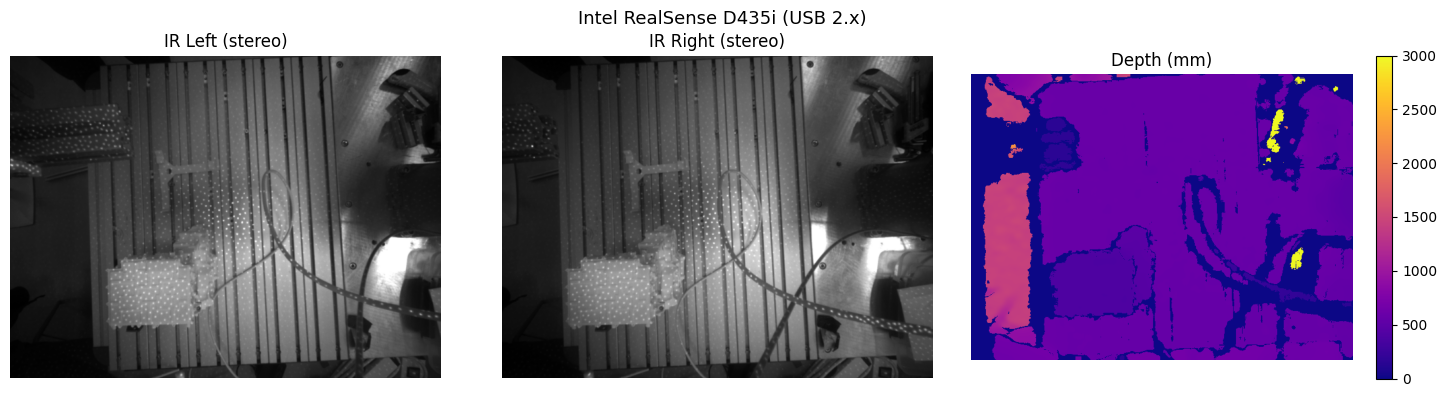

In [26]:
# Capture a single frame and display all streams
def capture_frame():
    for _ in range(10):  # warm up
        pipeline.wait_for_frames(timeout_ms=30000)

    frames = pipeline.wait_for_frames(timeout_ms=30000)

    depth   = np.asanyarray(frames.get_depth_frame().get_data())
    ir_left = np.asanyarray(frames.get_infrared_frame(1).get_data())
    ir_right= np.asanyarray(frames.get_infrared_frame(2).get_data())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Intel RealSense D435i (USB 2.x)", fontsize=13)

    axes[0].imshow(ir_left, cmap="gray")
    axes[0].set_title("IR Left (stereo)")
    axes[0].axis("off")

    axes[1].imshow(ir_right, cmap="gray")
    axes[1].set_title("IR Right (stereo)")
    axes[1].axis("off")

    im = axes[2].imshow(depth, cmap="plasma", vmin=0, vmax=3000)
    axes[2].set_title("Depth (mm)")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

capture_frame()

In [22]:
import os
import cv2
from datetime import datetime

def save_frame():
    for _ in range(5):
        pipeline.wait_for_frames(timeout_ms=30000)

    frames   = pipeline.wait_for_frames(timeout_ms=30000)
    ir_left  = np.asanyarray(frames.get_infrared_frame(1).get_data())
    ir_right = np.asanyarray(frames.get_infrared_frame(2).get_data())
    depth    = np.asanyarray(frames.get_depth_frame().get_data())

    os.makedirs("data", exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    cv2.imwrite(f"../data/ir_left_{ts}.png",  ir_left)
    cv2.imwrite(f"../data/ir_right_{ts}.png", ir_right)
    np.save(f"../data/depth_{ts}.npy", depth)

    print(f"Saved ../data/ir_left_{ts}.png")
    print(f"Saved ../data/ir_right_{ts}.png")
    print(f"Saved ../data/depth_{ts}.npy")

save_frame()

Saved ../data/ir_left_20260331_111721.png
Saved ../data/ir_right_20260331_111721.png
Saved ../data/depth_20260331_111721.npy


In [ ]:
# Live viewer — IR left + depth, with Stop button
stop_btn = widgets.Button(description="Stop", button_style="danger")
output = widgets.Output()
running = {"active": True}

def on_stop(b):
    running["active"] = False

stop_btn.on_click(on_stop)
display(stop_btn, output)

while running["active"]:
    frames = pipeline.wait_for_frames(timeout_ms=10000)
    ir_left = np.asanyarray(frames.get_infrared_frame(1).get_data())
    depth   = np.asanyarray(frames.get_depth_frame().get_data())

    with output:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(ir_left, cmap="gray")
        axes[0].set_title("IR Left")
        axes[0].axis("off")
        axes[1].imshow(depth, cmap="plasma", vmin=0, vmax=3000)
        axes[1].set_title("Depth")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

    time.sleep(0.07)  # ~14 fps

print("Stopped.")

Button(button_style='danger', description='Stop', style=ButtonStyle())

Output()

In [ ]:
# Stop pipeline when done
pipeline.stop()
print("Pipeline stopped.")